In [7]:
import torch
from tqdm import tqdm
from forward_solvers_numba.fem import V_h, Mesh
import os
import scipy.io as sio
import matplotlib.pyplot as plt
import cmocean as cmo
from forward_solvers_numba.eit import EIT
from forward_solvers_numba.fem import Mesh, V_h, dtn_map
from forward_solvers_numba.utils import generate_GCOORD, assemble_EL_connectivity, interpolate_pts
import numpy as np

In [8]:
problem = 'eit-circles'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_data = torch.load(f'data/{problem}-dataset-128.pt')['test']
gt = test_data[5].squeeze(0)
gt = gt.cpu().numpy()

(128, 128)


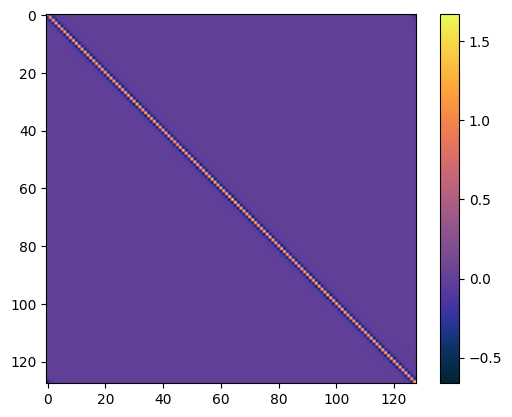

In [42]:
data_root = 'forward_solvers/mesh-data'
mesh_file = 'mesh_128_h05.mat'
img_size = 128
original_size = 128
pad_size = 0

nx          = img_size + 1
ny          = img_size + 1
lx          = 2
ly          = 2
nnodel      = 4  #number of nodes per element

# model parameters
nex         = nx-1
ney         = ny-1
nnod        = nx*ny #number of nodes
nel         = nex*ney #number of finite elements

img_size_down = original_size + 2 * pad_size
x = np.linspace(-1, 1, img_size_down)
y = np.linspace(-1, 1, img_size_down)
xx, yy = np.meshgrid(x, y)
img_points = np.stack([xx.ravel(), yy.ravel()]).T

# Generate a mesh for downsampling the original image. 
GCOORD_down = img_points.reshape((img_size_down, img_size_down, 2))
GCOORD_down = np.flip(GCOORD_down, axis=0)
GCOORD_down = GCOORD_down.reshape((-1, 2))
#generate square mesh and element connectivity
GCOORD = generate_GCOORD(lx, ly, nx, ny)
EL2NOD = assemble_EL_connectivity(nnod, nnodel, nex, nx)

mat_fname  = os.path.join(data_root, mesh_file)
mat_contents = sio.loadmat(mat_fname)

p = np.array(mat_contents['p'])
t = np.array(mat_contents['t']-1) 
vol_idx = mat_contents['vol_idx'].reshape((-1,))-1 
bdy_idx = mat_contents['bdy_idx'].reshape((-1,))-1 

mesh = Mesh(p, t, bdy_idx, vol_idx)
v_h = V_h(mesh)

centroids = np.mean(p[t], axis=1)  
sigma_vec = interpolate_pts(GCOORD_down, gt.flatten(), centroids)
dtn_gt, sol = dtn_map(v_h, sigma_vec)
print(dtn_gt.shape)
plt.imshow(dtn_gt, cmap=cmo.cm.thermal)
plt.colorbar()

In [25]:

import scipy.optimize as op
from scipy.optimize import Bounds
import scipy.io as sio
def generate_EIT_sol(num_iters, mesh, v_h, sigma_vec_true, noise):

    dtn_data, sol = dtn_map(v_h, sigma_vec_true)

    # add desired noise
    noise_data = np.random.uniform(-noise, noise, dtn_data.shape) * dtn_data
    dtn_data = dtn_data + noise_data

    # initial guess: 1 is value of background medium
    sigma_vec_0 = 1. + np.zeros(mesh.t.shape[0], dtype=np.float64)

    eit = EIT(v_h)
    eit.update_matrices(sigma_vec_0)

    def J(x):
        return eit.misfit(dtn_data, x)
    
    opt_tol = 1e-30

    bounds_l = [1. for _ in range(len(sigma_vec_0))]
    bounds_r = [np.inf for _ in range(len(sigma_vec_0))]
    bounds = Bounds(bounds_l, bounds_r)

    # t_i = time.time()
    res = op.minimize(J, sigma_vec_0, method='L-BFGS-B',
                      jac = True,
                      tol = opt_tol,
                      bounds=bounds, 
                      options={'maxiter': num_iters,
                                'disp': False, 'ftol':opt_tol, 'gtol':opt_tol}, 
                     )
                       # callback=callback)

    # t_f = time.time()

    return res.x

In [40]:
result = generate_EIT_sol(num_iters=2000, mesh=mesh, v_h=v_h, sigma_vec_true=sigma_vec, noise=0.01)

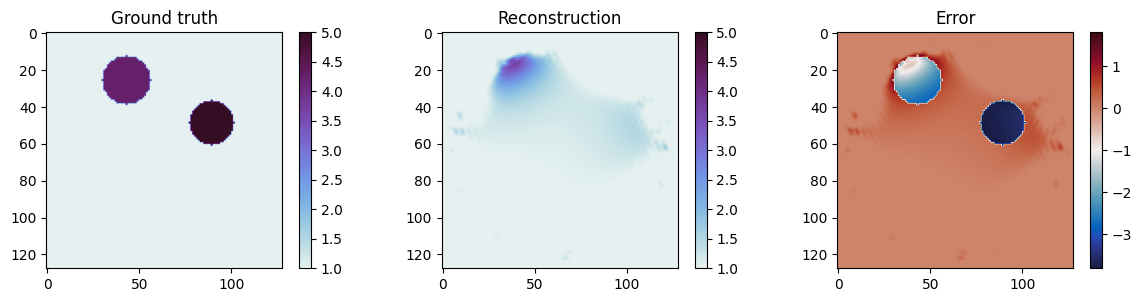

In [44]:
sq_img_true = 1. + np.zeros((nx-1) * (ny-1))
sq_img_pred = 1. + np.zeros((nx-1) * (ny-1))

interp_vals_true = interpolate_pts(centroids, sigma_vec, GCOORD)
interp_vals_pred = interpolate_pts(centroids, result, GCOORD)
for iel in range(0,nel):
    ECOORD_true = np.take(interp_vals_true, EL2NOD[iel, :], axis=0)
    ECOORD_pred = np.take(interp_vals_pred, EL2NOD[iel, :], axis=0)
    
    #based on ECOORD pts, average them out to find pixel value 
    sq_img_true[iel] = np.mean(ECOORD_true)
    sq_img_pred[iel] = np.mean(ECOORD_pred)
    

sq_img_true = np.flip(sq_img_true.reshape((nx-1, ny-1)), axis=0)
sq_img_pred = np.flip(sq_img_pred.reshape((nx-1, ny-1)), axis=0)

sigma_true = np.zeros((len(centroids)))
sigma_pred = np.zeros((len(centroids)))
imgs_true = np.zeros((img_size, img_size))
imgs_pred = np.zeros((img_size, img_size))

sigma_true[...] = sigma_vec
sigma_pred[...] = result
imgs_true[...] = sq_img_true
imgs_pred[...] = sq_img_pred
# plot the final result and error
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
plt.imshow(gt, cmap=cmo.cm.dense, vmin=1, vmax=5)
plt.title('Ground truth')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(imgs_pred, cmap=cmo.cm.dense, vmin=1, vmax=5)
plt.title('Reconstruction')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(imgs_pred- gt, cmap=cmo.cm.balance)
plt.title('Error')
plt.colorbar()
plt.tight_layout()
plt.show()